#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

#### 2) Loading Data:

In [2]:
df = pd.read_csv('EnergyProduction.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,EnergyIndex
DATE,
1970-01-01,43.0869
1970-02-01,42.5577
1970-03-01,41.6215
1970-04-01,40.1982
1970-05-01,39.9321


In [4]:
df.shape

(240, 1)

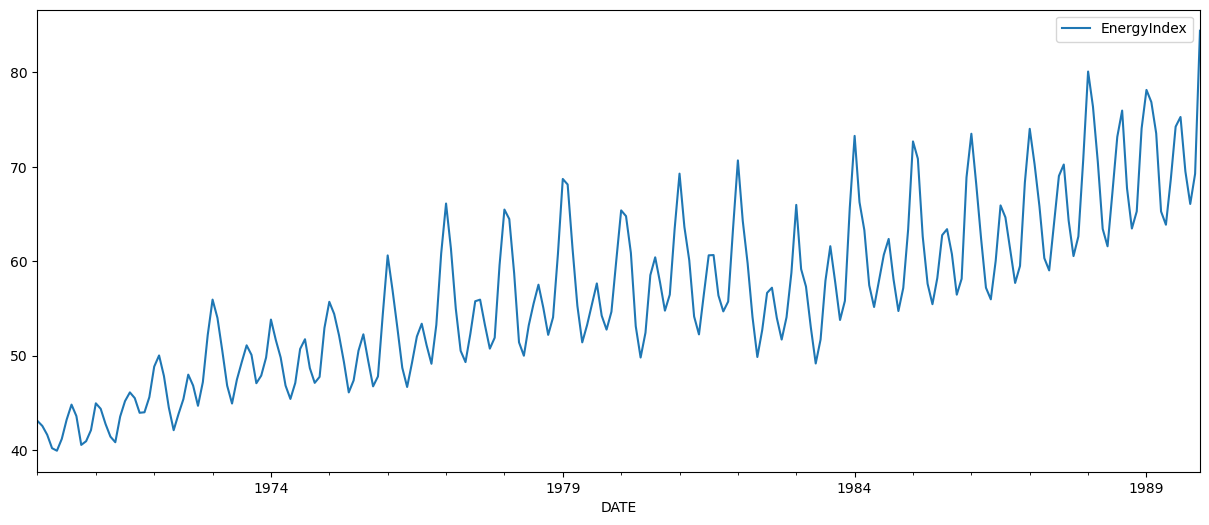

In [5]:
# Plotting Data:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

In [6]:
df.index

DatetimeIndex(['1970-01-01', '1970-02-01', '1970-03-01', '1970-04-01',
               '1970-05-01', '1970-06-01', '1970-07-01', '1970-08-01',
               '1970-09-01', '1970-10-01',
               ...
               '1989-03-01', '1989-04-01', '1989-05-01', '1989-06-01',
               '1989-07-01', '1989-08-01', '1989-09-01', '1989-10-01',
               '1989-11-01', '1989-12-01'],
              dtype='datetime64[ns]', name='DATE', length=240, freq=None)

In [7]:
# Adding Frequency to Index:

df.index.freq = 'MS' #Month Start

In [8]:
df.index

DatetimeIndex(['1970-01-01', '1970-02-01', '1970-03-01', '1970-04-01',
               '1970-05-01', '1970-06-01', '1970-07-01', '1970-08-01',
               '1970-09-01', '1970-10-01',
               ...
               '1989-03-01', '1989-04-01', '1989-05-01', '1989-06-01',
               '1989-07-01', '1989-08-01', '1989-09-01', '1989-10-01',
               '1989-11-01', '1989-12-01'],
              dtype='datetime64[ns]', name='DATE', length=240, freq='MS')

##### Simple Exponential Smoothing:

In [10]:
df['SMA_12mths'] = df['EnergyIndex'].rolling(window= 12).mean()
df.head(15)

,EnergyIndex,SMA_12mths
DATE,,
1970-01-01,43.0869,NaN
1970-02-01,42.5577,NaN
1970-03-01,41.6215,NaN
1970-04-01,40.1982,NaN
1970-05-01,39.9321,NaN
1970-06-01,41.1847,NaN
1970-07-01,43.2230,NaN
1970-08-01,44.8138,NaN
1970-09-01,43.6007,NaN


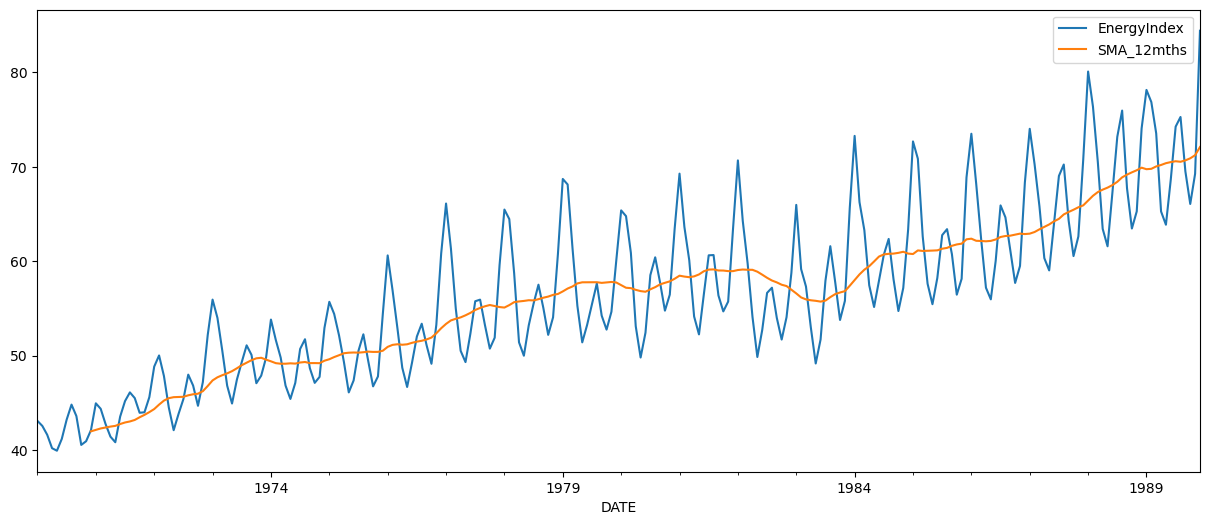

In [11]:
# Plotting SMA:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

##### Exponentially Weighted Moving Average (EWMA) for 12 Months or Simple Exponential Smoothing using Statsmodels:

In [12]:
df['SES_12mths'] = SimpleExpSmoothing(endog= df['EnergyIndex']).fit(smoothing_level= 2/(12+1),
                                                                   optimized= False).fittedvalues.shift(-1)

In [13]:
df.head()

,EnergyIndex,SMA_12mths,SES_12mths
DATE,,,
1970-01-01,43.0869,NaN,43.086900
1970-02-01,42.5577,NaN,43.005485
1970-03-01,41.6215,NaN,42.792564
1970-04-01,40.1982,NaN,42.393431
1970-05-01,39.9321,NaN,42.014765


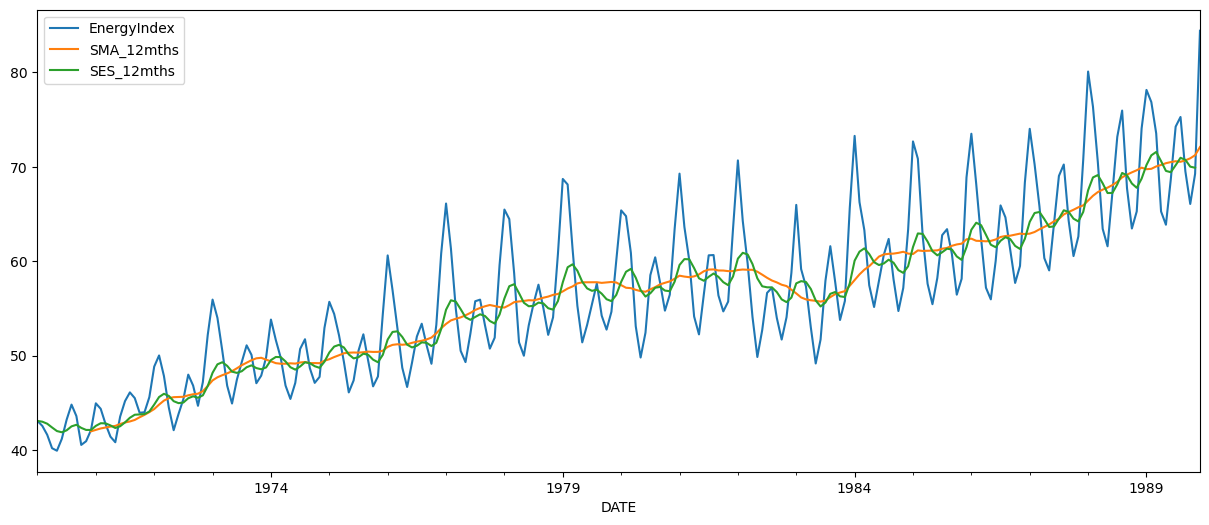

In [14]:
# Plotting:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

##### Double Exponential Smoothing Using Holt Winters Multiplicative:

In [15]:
df['DES_12mths'] = ExponentialSmoothing(endog= df['EnergyIndex'],
                                       trend= 'mul').fit().fittedvalues.shift(-1)

In [16]:
df.head()

,EnergyIndex,SMA_12mths,SES_12mths,DES_12mths
DATE,,,,
1970-01-01,43.0869,NaN,43.086900,43.114529
1970-02-01,42.5577,NaN,43.005485,42.584989
1970-03-01,41.6215,NaN,42.792564,41.648189
1970-04-01,40.1982,NaN,42.393431,40.223976
1970-05-01,39.9321,NaN,42.014765,39.957706


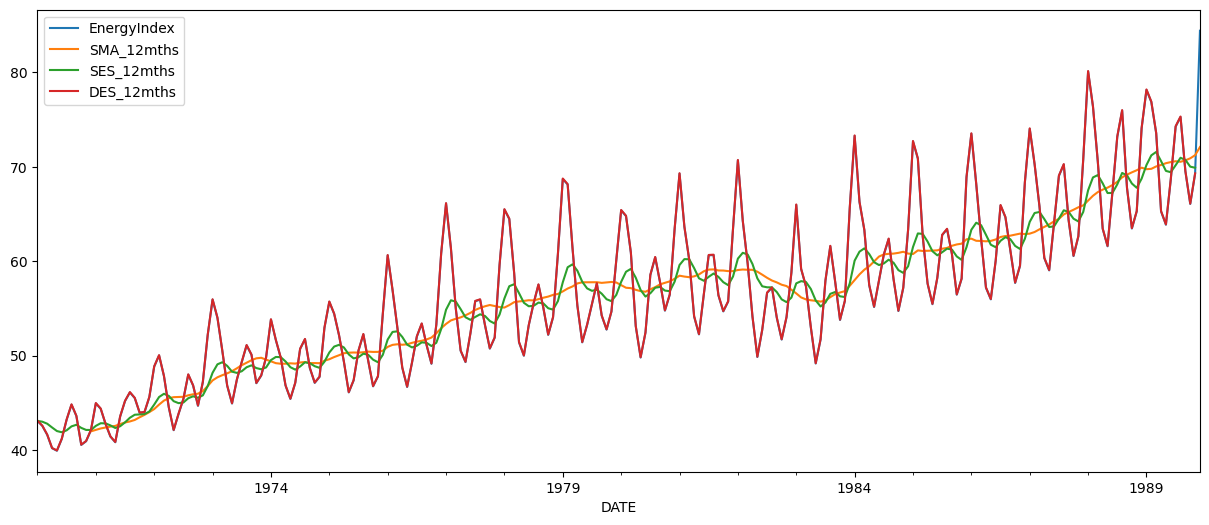

In [17]:
# Plotting:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

##### Triple Exponential Smoothing Using Holt Winters Multiplicative:

In [18]:
df['TES_12mths'] = ExponentialSmoothing(endog= df['EnergyIndex'],
                                       trend= 'mul', seasonal= 'mul',
                                       seasonal_periods= 12).fit().fittedvalues

In [19]:
df.head()

,EnergyIndex,SMA_12mths,SES_12mths,DES_12mths,TES_12mths
DATE,,,,,
1970-01-01,43.0869,NaN,43.086900,43.114529,43.085319
1970-02-01,42.5577,NaN,43.005485,42.584989,41.068109
1970-03-01,41.6215,NaN,42.792564,41.648189,39.724698
1970-04-01,40.1982,NaN,42.393431,40.223976,37.961970
1970-05-01,39.9321,NaN,42.014765,39.957706,38.600741


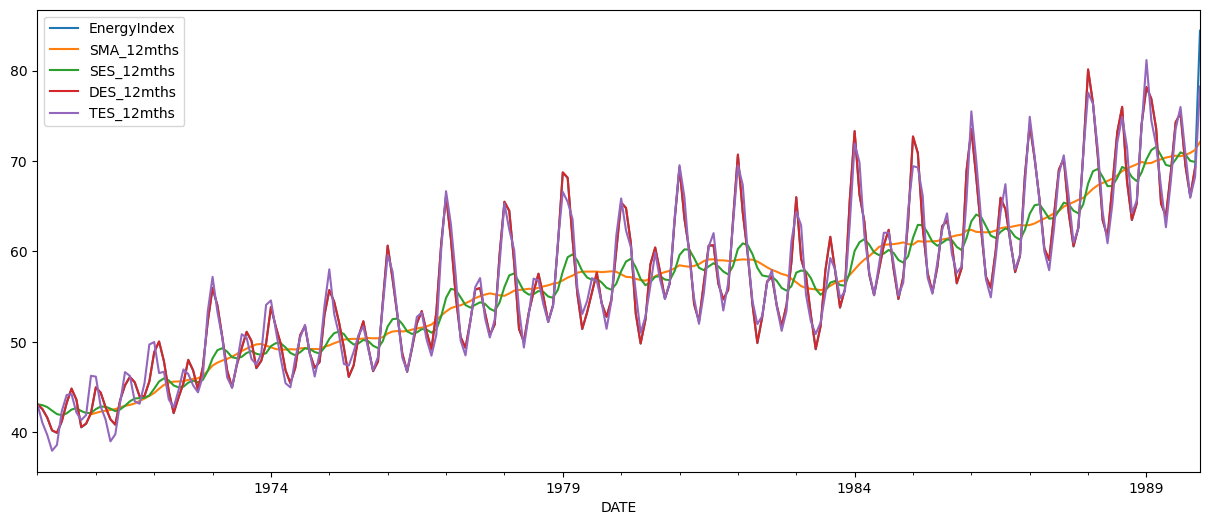

In [20]:
# Plotting:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

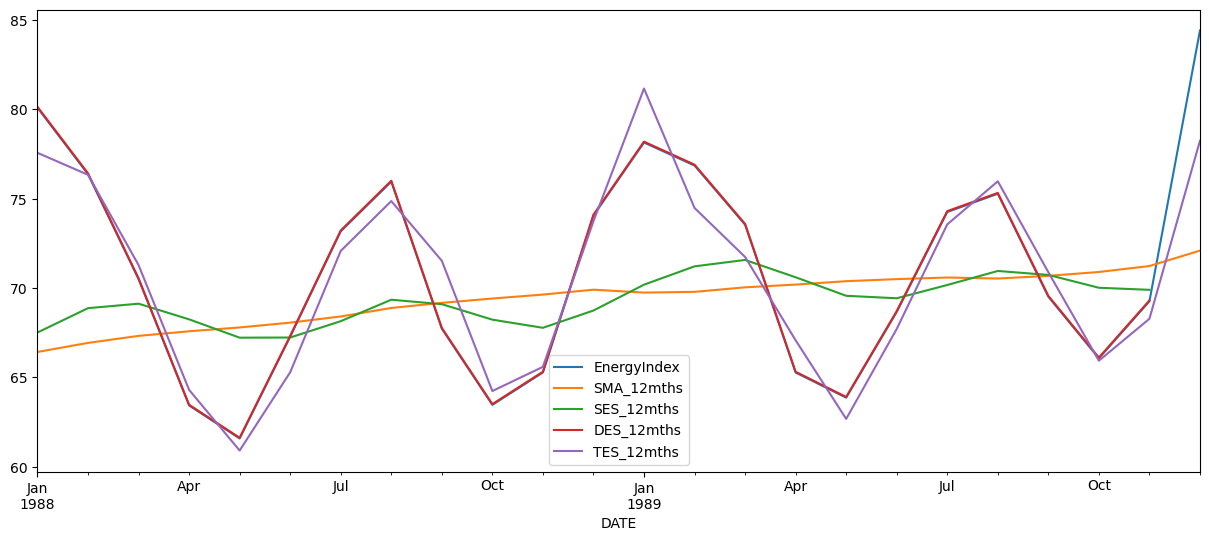

In [21]:
# Zooming in too see last 2 years of data:

df[-24:].plot(kind= 'line', figsize= (15,6))
plt.show()